In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import P300
from hoda.hoda import HODA,BTTDA
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from matplotlib import style
plt.style.use('default')

In [3]:
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #bi2013a(),
    #bi2014a(),
    #bi2014b(),
    #bi2015a(),
    #bi2015b(),
    BNCI2014008(),
    #BNCI2014009(),
    #BNCI2015003(),
    #DemonsP300(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019()

]
evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    suffix="hoda",
    overwrite=True,
    random_state=42,
    n_jobs=-1,
    #data_size=dict(
    #    policy='per_class',
    #    value=[10]
    #),
    #n_perms=[2],
)

In [4]:
import tensorly as tl
tl.set_backend('numpy', local_threadsafe=False)

In [5]:
import numpy as np

class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels,
                                 data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)



def lagged_tensor(X, y=None):    
    window = 0.4
    max_lag = 0.4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

def reshape(X, y=None):
    return X.reshape((X.shape[0],-1))

def tril_reshape(X):
    tril_idc = np.tril_indices(X.shape[-1])
    Xt = np.zeros((*X.shape[:2], len(tril_idc[0])))
    for i in range(Xt.shape[0]):
        for c in range(Xt.shape[1]):
            Xt[i,c] = X[i,c][tril_idc]
    Xt = Xt.reshape((Xt.shape[0],-1))
    return Xt


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC
from sklearn.feature_selection import SelectPercentile, f_classif
from mne.decoding import Scaler
from hoda.hoda import HODA
import cupy

pipelines = dict()


pipelines['HODA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=64,
        rank=None,
        tol=1e-3,
        init ='mlsvd',
        shrinkage=('lw','lw'),
        toeplitz=(1,),
        solver='lfl',
        verbose=False,
        taper=False,
        keep_train_info=False
    ),
    FunctionTransformer(reshape),
    LinearDiscriminantAnalysis(),
)

"""
pipelines['BTTDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    BTTDA(
        n_blocks=None,
        hoda_params=dict(
            max_iter=64,
            rank=None,
            tol=1e-3,
            init ='mlsvd',
            shrinkage=('lw','lw'),
            toeplitz=(1,),
            solver='lfl',
            verbose=False,
            taper=False,
        ),
    ),
    #SelectPercentile(percentile=50, score_func=f_classif),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
"""
pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)


In [7]:
results = evaluation.process(pipelines)

008-2014-WithinSession: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:47<00:00,  5.92s/it]


In [8]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.843990,0.389003,4200.0,1,session_0,8,1,008-2014,tLDA
1,0.820810,0.178491,4200.0,2,session_0,8,1,008-2014,tLDA
2,0.892798,0.181009,4200.0,3,session_0,8,1,008-2014,tLDA
3,0.815190,0.170651,4200.0,4,session_0,8,1,008-2014,tLDA
4,0.866292,0.171631,4200.0,5,session_0,8,1,008-2014,tLDA
5,0.899024,0.181758,4200.0,6,session_0,8,1,008-2014,tLDA
6,0.882051,0.046204,4200.0,7,session_0,8,1,008-2014,tLDA
7,0.954788,0.046961,4200.0,8,session_0,8,1,008-2014,tLDA
8,0.827294,0.933158,4200.0,1,session_0,8,1,008-2014,HODA
9,0.765233,0.371892,4200.0,2,session_0,8,1,008-2014,HODA


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


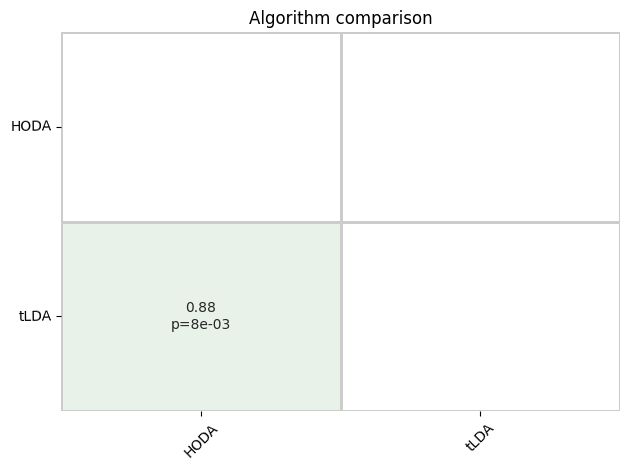

In [9]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

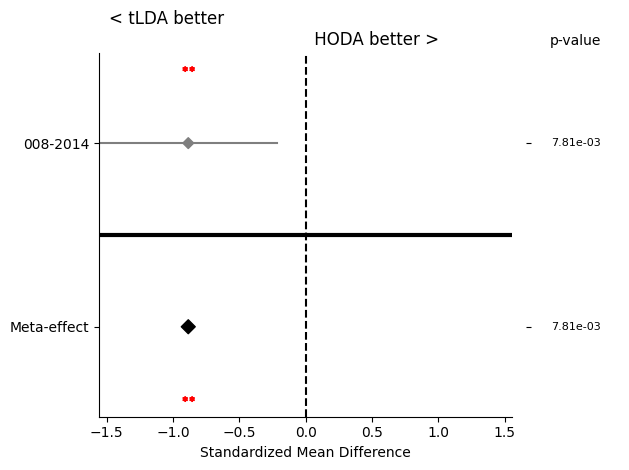

In [10]:

_=meta_analysis_plot(stats,  "HODA","tLDA")


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


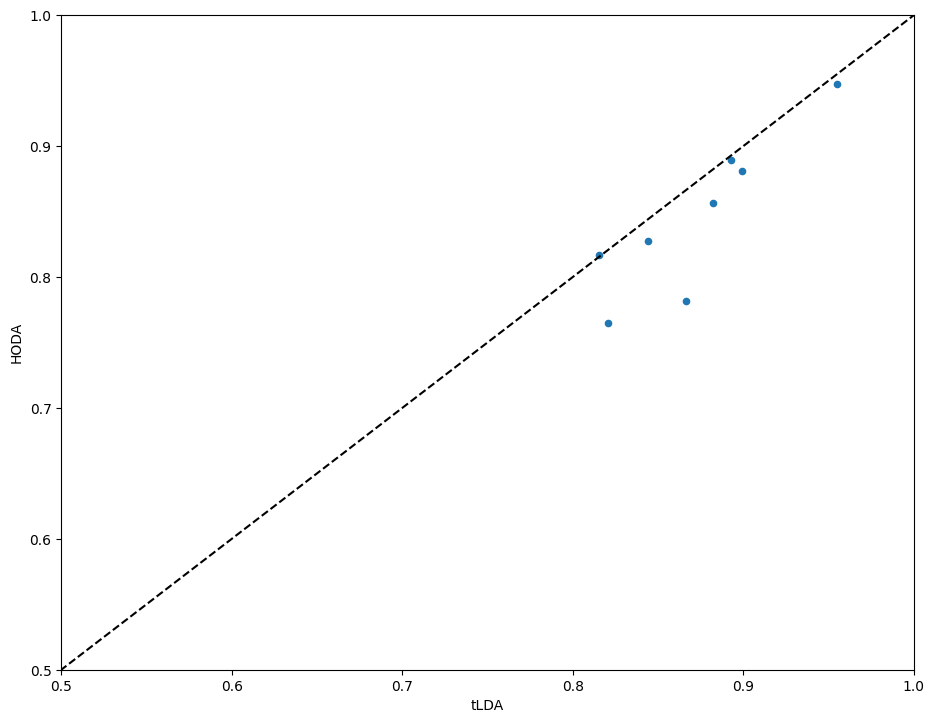

In [11]:
_ = paired_plot(results, "tLDA", "HODA")
